<a href="https://colab.research.google.com/github/danah113/IT326-Data-mining-Project/blob/main/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

mushroom = fetch_ucirepo(id=73)

X = mushroom.data.features   # columns
y = mushroom.data.targets    # rows
df = pd.concat([X, y], axis=1)

#Missing values and their analysis & Statistical summaries:
>The dataset contains a single column with missing values: stalk-root, which has 2,480 missing entries out of 8,124 total rows (about 30.5%). All other 21 attributes are fully complete. <br>Notably, while the original UCI file represents missing values using the symbol '?', the ucimlrepo package we used already converts these into standard NaN values automatically, which is why our direct '?' search returned zero across all columns. <br>Since missing values are concentrated so heavily in one attribute and represent a substantial portion of the dataset, dropping these rows would discard nearly a third of our data.<br> During preprocessing, we will therefore consider treating the missing values as their own category rather than removing the affected rows.

In [ ]:
print("Standard NaN missing values:")
print(df.isnull().sum())


Standard NaN missing values:
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
poisonous                      0
dtype: int64


In [ ]:
print("\n'?' values per column:")
print((df == '?').sum())


'?' values per column:
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
poisonous                   0
dtype: int64


In [ ]:
df.describe(include='object') #Statistical summary for categorical data

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,poisonous
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,6,4,10,2,9,2,2,2,12,2,...,9,9,1,4,3,5,9,6,7,2
top,x,y,n,f,n,f,c,b,b,t,...,w,w,p,w,o,p,w,v,d,e
freq,3656,3244,2284,4748,3528,7914,6812,5612,1728,4608,...,4464,4384,8124,7924,7488,3968,2388,4040,3148,4208


In [ ]:
print(df['odor'].value_counts()) #Value counts for a few key columns
print(df['habitat'].value_counts())
print(df['poisonous'].value_counts())

odor
n    3528
f    2160
s     576
y     576
a     400
l     400
p     256
c     192
m      36
Name: count, dtype: int64
habitat
d    3148
g    2148
p    1144
l     832
u     368
m     292
w     192
Name: count, dtype: int64
poisonous
e    4208
p    3916
Name: count, dtype: int64


##Class distribution plot:

Class Counts:
poisonous
e    4208
p    3916
Name: count, dtype: int64

Class Percentages:
poisonous
e    51.8
p    48.2
Name: count, dtype: float64


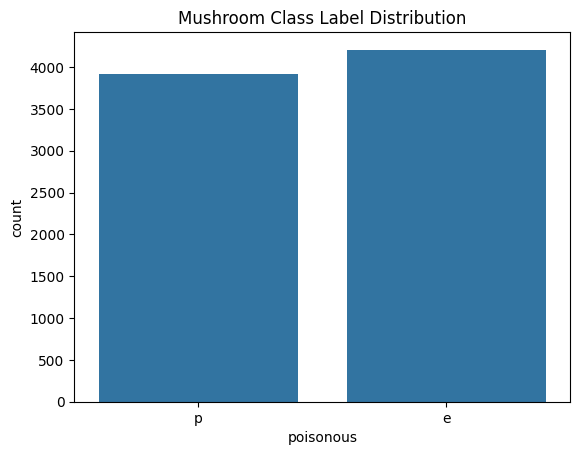

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

class_counts = df['poisonous'].value_counts()
class_percentages = (class_counts / len(df)) * 100

print("Class Counts:")
print(class_counts)

print("\nClass Percentages:")
print(class_percentages.round(2))

sns.countplot(x='poisonous', data=df)
plt.title('Mushroom Class Label Distribution')
plt.show()

The class lable distribution shows that the dataset contains 4,208 edible mushrooms (51.8%) and 3,916 poisonous mushrooms (48.2%). The two classes are relatively balanced because their counts and percentages are close. This information helped us determine that class balancing is not required during preprocessing, since neither class strongly dominates the dataset.

##Bar chart:

##Pie chart:

#-Preproccessing techniques
##Encoding:

**Encoding.** All attributes in the Mushroom dataset, including the class label, are nominal and stored as letters, while most ML algorithms require numeric input.

- Missing values in **stalk-root** were first replaced with a new category, "missing", to keep ~30% of the data.
- **Label Encoding** was applied to attributes with two or fewer values (e.g. bruises, gill-size), since 0/1 creates no false order.
- **One-Hot Encoding** was applied to attributes with more than two values (e.g. odor, habitat), to avoid implying an order between categories.
- The class label was mapped to edible = 0 and poisonous = 1.

**Result:** all columns are now numeric and ready for feature selection and modeling.


In [ ]:
 ### Before Encoding
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
df_encoded['stalk-root'] = df_encoded['stalk-root'].fillna('missing')

target = 'poisonous'
features = [c for c in df_encoded.columns if c != target]

print("Before encoding:")
display(df_encoded[['cap-shape', 'bruises', 'odor', 'stalk-root', 'habitat', target]].head())


Before encoding:


,cap-shape,bruises,odor,stalk-root,habitat,poisonous
0,x,t,p,e,u,p
1,x,t,a,c,g,e
2,b,t,l,c,m,e
3,x,t,p,e,u,p
4,x,f,n,e,g,e


In [ ]:
	### Encoding
binary_cols = [c for c in features if df_encoded[c].nunique() <= 2]
multi_cols = [c for c in features if df_encoded[c].nunique() > 2]

for c in binary_cols:
    df_encoded[c] = LabelEncoder().fit_transform(df_encoded[c])

df_encoded = pd.get_dummies(df_encoded, columns=multi_cols, dtype=int)
df_encoded[target] = df_encoded[target].map({'e': 0, 'p': 1})

print("Label encoded:", binary_cols)
print("One-hot encoded:", multi_cols)
print("Shape before:", df.shape, "| Shape after:", df_encoded.shape)



Label encoded: ['bruises', 'gill-attachment', 'gill-spacing', 'gill-size', 'stalk-shape', 'veil-type']
One-hot encoded: ['cap-shape', 'cap-surface', 'cap-color', 'odor', 'gill-color', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']
Shape before: (8124, 23) | Shape after: (8124, 113)


In [ ]:
### After Encoding
print("After encoding:")
display(df_encoded.head())
print("Non-numeric columns left:", df_encoded.select_dtypes(exclude='number').columns.tolist())


After encoding:


,bruises,gill-attachment,gill-spacing,gill-size,stalk-shape,veil-type,poisonous,cap-shape_b,cap-shape_c,cap-shape_f,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,1,1,0,1,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,1,0
1,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,1,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
3,1,1,0,1,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,1,0
4,0,1,1,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


Non-numeric columns left: []


##Feature Selection & Noise cleaning:

In [2]:
df_processed = df.copy()

mode_value = df_processed['stalk-root'].mode()[0]
print(f"Most frequent stalk-root category: '{mode_value}'")

df_processed['stalk-root'] = df_processed['stalk-root'].fillna(mode_value)

print(f"Remaining missing values after imputation: {df_processed['stalk-root'].isnull().sum()}")

Most frequent stalk-root category: 'b'
Remaining missing values after imputation: 0


In [ ]:
constant_cols = [col for col in df_processed.columns if df_processed[col].nunique() == 1]
print(f"Constant (uninformative) columns found: {constant_cols}")

df_processed = df_processed.drop(columns=constant_cols)
print(f"Shape after removing constant columns: {df_processed.shape}")

Constant (uninformative) columns found: ['veil-type']
Shape after removing constant columns: (8124, 22)


In [ ]:
from sklearn.feature_selection import SelectKBest, chi2

df_processed = df_encoded.copy()

X_features = df_processed.drop(columns=['poisonous'])
y_target = df_processed['poisonous']

selector = SelectKBest(score_func=chi2, k=15)  # select the top 15 most relevant features
X_selected = selector.fit_transform(X_features, y_target)

selected_columns = X_features.columns[selector.get_support()]
print(f"Selected features ({len(selected_columns)}):")
print(list(selected_columns))

df_processed = pd.concat(
    [pd.DataFrame(X_selected, columns=selected_columns), y_target.reset_index(drop=True)],
    axis=1
)
print(f"Shape after feature selection: {df_processed.shape}")

Selected features (15):
['bruises', 'gill-spacing', 'gill-size', 'odor_f', 'odor_n', 'gill-color_b', 'stalk-surface-above-ring_k', 'stalk-surface-below-ring_k', 'ring-type_l', 'ring-type_p', 'spore-print-color_h', 'spore-print-color_k', 'spore-print-color_n', 'spore-print-color_w', 'population_v']
Shape after feature selection: (8124, 16)


In [ ]:
### Save the Final Preprocessed Dataset
df_processed.to_csv('Preprocessed_dataset.csv', index=False)
print(f"Saved Preprocessed_dataset.csv with shape {df_processed.shape}")

Saved Preprocessed_dataset.csv with shape (8124, 16)
